In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("../data/airpods_final_clean.csv")

df.head()

,product_name,brand,price,original_price,discount_percent,ratings_count,seller,seller_rating_percent,ship_on_time_percent,review_rating,written_review,reviewer,bought_date,review_time,is_purchased,review_images_count,product_url
0,TWS Air pro Black Air pod_ with Super Sound & ...,NaN,789.0,NaN,NaN,11.0,Cano collection,NaN,NaN,5,omg the quality is very amazing I am very happ...,D***r,12 Aug 2026,2 weeks ago,True,1,https://www.daraz.pk/products/_-10-i1965762603...
1,Wireless Earbuds Headphones Bluetooth Earpods ...,NaN,323.0,NaN,NaN,187.0,AS SHOP 1581614841,NaN,NaN,5,𝐁𝐞𝐭𝐭𝐞𝐫 𝐐𝐮𝐚𝐥𝐢𝐭𝐲 Sound Quality:100% Battery Life...,0***0,10 Aug 2026,3 weeks ago,True,1,https://www.daraz.pk/products/-i1964603364.html
2,"Airbuds, Earbuds, Wireless Earbuds, Bluetooth ...",NaN,324.0,NaN,NaN,16.0,AS SHOP 1581614841,NaN,NaN,5,boht buri service hai Jo cheez dikhao us se 10...,Naveed,29 Aug 2026,2 days ago,True,1,https://www.daraz.pk/products/tws-hd-enc-led-i...
3,Original M10 & M90 TWS AIRPODS Wireless Earpho...,NaN,719.0,NaN,NaN,85.0,(Hania Collection Lahore),NaN,NaN,5,Totally Satisfied with the Quality of i12produ...,doopersuper534,09 Dec 2023,25 Dec 2023,True,6,https://www.daraz.pk/products/original-m10-m90...
4,New Air Pro True Wireless Airbuds Bluetooth Ea...,NaN,849.0,NaN,NaN,20.0,as online mart,NaN,NaN,5,Comfort: comfortable bi bhot hai easy se ear m...,a***a,07 Aug 2026,3 weeks ago,True,4,https://www.daraz.pk/products/-i1967525584.html


In [4]:
df.shape

(500, 17)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   product_name           500 non-null    str    
 1   brand                  0 non-null      float64
 2   price                  500 non-null    float64
 3   original_price         0 non-null      float64
 4   discount_percent       0 non-null      float64
 5   ratings_count          476 non-null    float64
 6   seller                 500 non-null    str    
 7   seller_rating_percent  0 non-null      float64
 8   ship_on_time_percent   0 non-null      float64
 9   review_rating          500 non-null    int64  
 10  written_review         500 non-null    str    
 11  reviewer               500 non-null    str    
 12  bought_date            500 non-null    str    
 13  review_time            500 non-null    str    
 14  is_purchased           500 non-null    bool   
 15  review_images_cou

In [6]:
# Remove completely empty columns

empty_columns = df.columns[df.isna().all()]

print("Empty columns:")
print(empty_columns)

df = df.drop(columns=empty_columns)

print("\nNew shape:")
print(df.shape)

Empty columns:
Index(['brand', 'original_price', 'discount_percent', 'seller_rating_percent',
       'ship_on_time_percent'],
      dtype='str')

New shape:
(500, 12)


In [7]:
# Check missing values

print(df.isnull().sum())

product_name            0
price                   0
ratings_count          24
seller                  0
review_rating           0
written_review          0
reviewer                0
bought_date             0
review_time             0
is_purchased            0
review_images_count     0
product_url             0
dtype: int64


In [8]:
# Fill missing ratings_count values with median

median_rating_count = df["ratings_count"].median()

df["ratings_count"] = df["ratings_count"].fillna(median_rating_count)

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
product_name           0
price                  0
ratings_count          0
seller                 0
review_rating          0
written_review         0
reviewer               0
bought_date            0
review_time            0
is_purchased           0
review_images_count    0
product_url            0
dtype: int64


In [9]:
# Check duplicate rows

duplicates = df.duplicated().sum()

print("Duplicate rows:")
print(duplicates)

Duplicate rows:
0


In [10]:
# Clean text columns by removing extra spaces

text_columns = df.select_dtypes(include="object").columns

for column in text_columns:
    df[column] = df[column].str.strip()

print("Text columns cleaned:")
print(list(text_columns))

Text columns cleaned:
['product_name', 'seller', 'written_review', 'reviewer', 'bought_date', 'review_time', 'product_url']


C:\Users\hp\AppData\Local\Temp\ipykernel_9600\3560519988.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = df.select_dtypes(include="object").columns


In [11]:
# Convert bought_date into proper date format

df["bought_date"] = pd.to_datetime(
    df["bought_date"],
    errors="coerce"
)

print(df["bought_date"].head())
print("\nData type:")
print(df["bought_date"].dtype)

0   2026-08-12
1   2026-08-10
2   2026-08-29
3   2023-12-09
4   2026-08-07
Name: bought_date, dtype: datetime64[us]

Data type:
datetime64[us]


In [12]:
# Final dataset check

print("Final dataset shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

Final dataset shape:
(500, 12)

Columns:
['product_name', 'price', 'ratings_count', 'seller', 'review_rating', 'written_review', 'reviewer', 'bought_date', 'review_time', 'is_purchased', 'review_images_count', 'product_url']


In [31]:
# Save cleaned dataset

output_path = "../output/airpods_cleaned.csv"

df.to_csv(output_path, index=False)

print("File saved successfully!")
print(output_path)

File saved successfully!
../output/airpods_cleaned.csv


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [15]:
df.describe()

,price,ratings_count,review_rating,bought_date,review_images_count
count,500.000000,500.000000,500.000000,500,500.000000
mean,847.136000,365.954000,4.836000,2025-09-28 06:34:33.600000,2.192000
min,229.000000,1.000000,1.000000,2020-01-12 00:00:00,0.000000
25%,686.500000,16.000000,5.000000,2024-12-05 00:00:00,1.000000
50%,739.000000,36.000000,5.000000,2026-02-19 12:00:00,2.000000
75%,849.000000,187.000000,5.000000,2026-08-01 00:00:00,3.000000
max,5499.000000,6150.000000,5.000000,2026-09-01 00:00:00,6.000000
std,530.692459,1049.093224,0.652653,NaN,1.774665


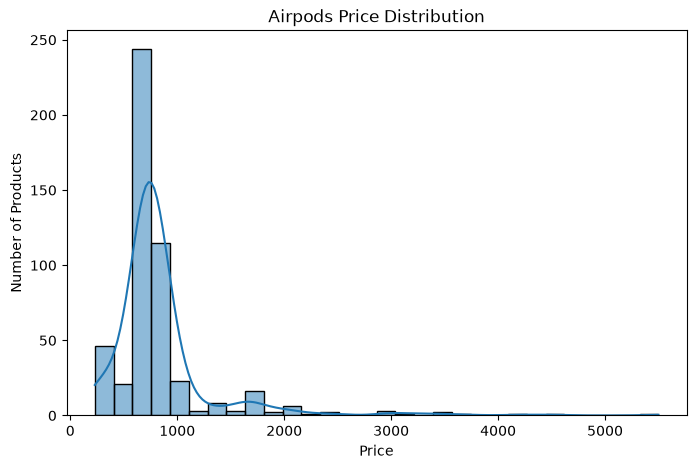

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(df["price"], bins=30, kde=True)

plt.title("Airpods Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Products")

plt.show()

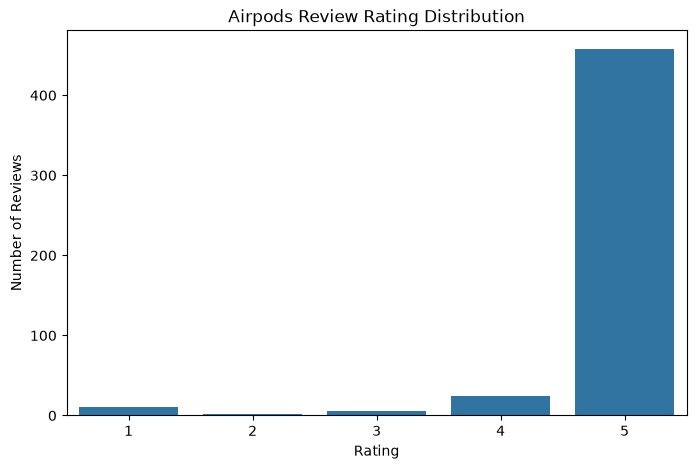

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(x=df["review_rating"])

plt.title("Airpods Review Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.show()

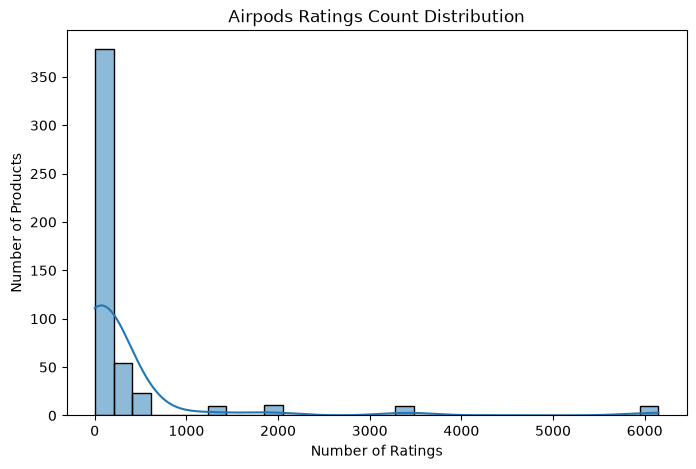

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df["ratings_count"], bins=30, kde=True)

plt.title("Airpods Ratings Count Distribution")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Products")

plt.show()

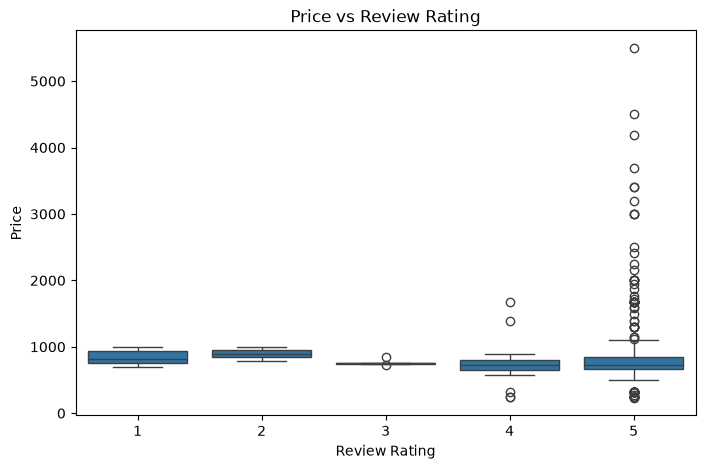

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="review_rating",
    y="price",
    data=df
)

plt.title("Price vs Review Rating")
plt.xlabel("Review Rating")
plt.ylabel("Price")

plt.show()

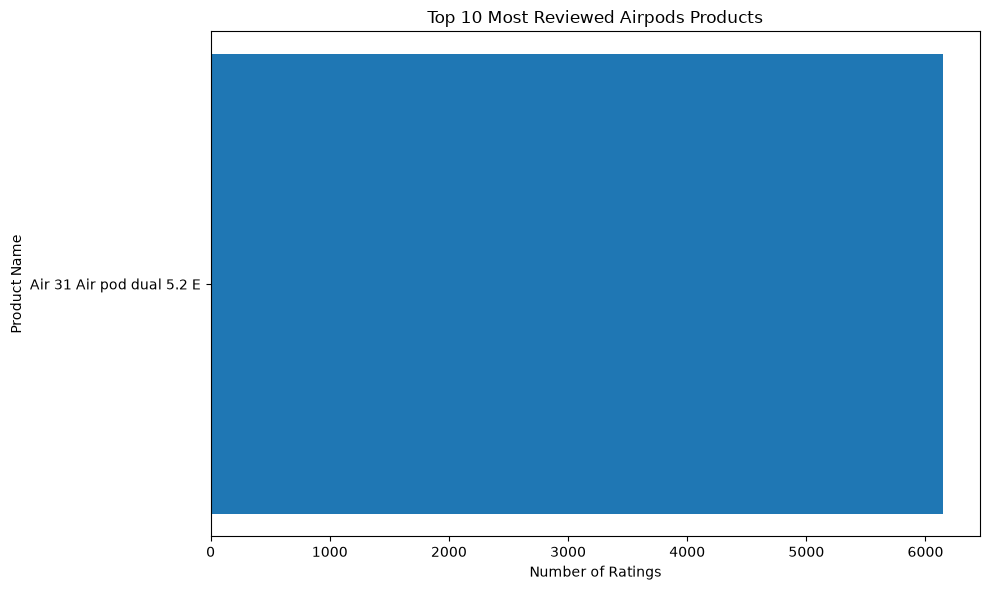

In [22]:
top_products = df.nlargest(10, "ratings_count").copy()

# Short names
top_products["short_name"] = top_products["product_name"].str[:25]

# Sort for better display
top_products = top_products.sort_values("ratings_count")

plt.figure(figsize=(10,6))

plt.barh(
    top_products["short_name"],
    top_products["ratings_count"]
)

plt.title("Top 10 Most Reviewed Airpods Products")
plt.xlabel("Number of Ratings")
plt.ylabel("Product Name")

plt.tight_layout()
plt.show()

In [23]:
top_products = df.nlargest(10, "ratings_count")

top_products[["product_name", "price", "review_rating", "ratings_count"]]

,product_name,price,review_rating,ratings_count
6,Air 31 Air pod dual 5.2 Earbuds handfree bluet...,699.0,5,6150.0
266,Air 31 Air pod dual 5.2 Earbuds handfree bluet...,699.0,5,6150.0
267,Air 31 Air pod dual 5.2 Earbuds handfree bluet...,699.0,5,6150.0
268,Air 31 Air pod dual 5.2 Earbuds handfree bluet...,699.0,5,6150.0
269,Air 31 Air pod dual 5.2 Earbuds handfree bluet...,699.0,4,6150.0
270,Air 31 Air pod dual 5.2 Earbuds handfree bluet...,699.0,5,6150.0
271,Air 31 Air pod dual 5.2 Earbuds handfree bluet...,699.0,5,6150.0
272,Air 31 Air pod dual 5.2 Earbuds handfree bluet...,699.0,5,6150.0
273,Air 31 Air pod dual 5.2 Earbuds handfree bluet...,699.0,5,6150.0
274,Air 31 Air pod dual 5.2 Earbuds handfree bluet...,699.0,5,6150.0


In [24]:
id_counts = df["product_name"].value_counts()

id_counts.head(10)

product_name
Wireless Earbuds Headphones Bluetooth Earpods Sports Stereo Airbuds Noise Canceling Headphone Microphone Speaker with LED light headphones                                                                                                                      24
Airbuds, Earbuds, Wireless Earbuds, Bluetooth Earbuds, TWS Earbuds, Airbuds Bluetooth Earphones, Wireless Earphones, Touch Control, HD Sound, Deep Bass, ENC Noise Cancellation, Gaming Earbuds, LED Display, Long Battery                                      20
EARBUDS AIR 31 AIRPODS WIRELESS EARBUDS WITH CRYSTAL TRANSPARENT CASE WITH TYPE C CHARGING|EARBUDS BLUETOOTH 5.3 | NEW MODEL AIR 31                                                                                                                             13
Air 31 Airpods - Air31 Earbuds Wireless Earbuds - Air 31 Earbuds - Transparent Airpods Air 31 - Transparent Earbuds Air 31 TWS Earbuds - Airbuds - Earpods - Ear Buds Wireless - Air Buds - Bluetooth Earphones   

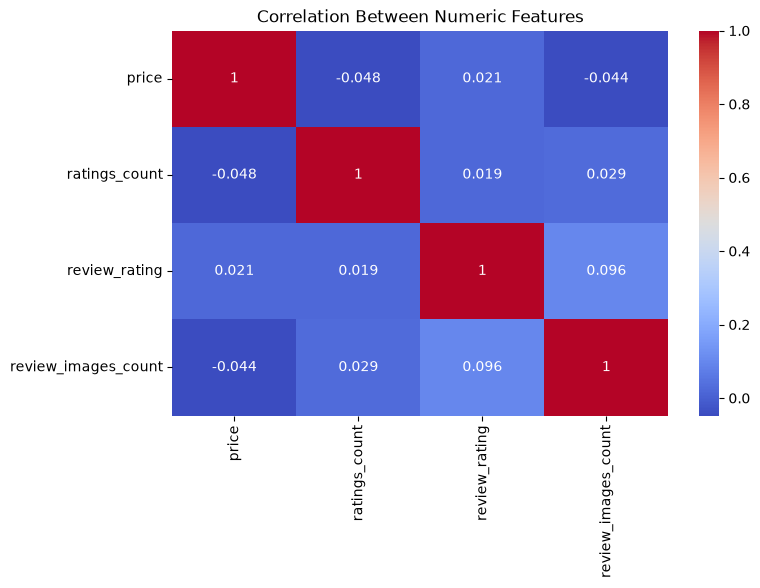

In [25]:
plt.figure(figsize=(8,5))

numeric_df = df.select_dtypes(include=["int64","float64"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Numeric Features")

plt.show()

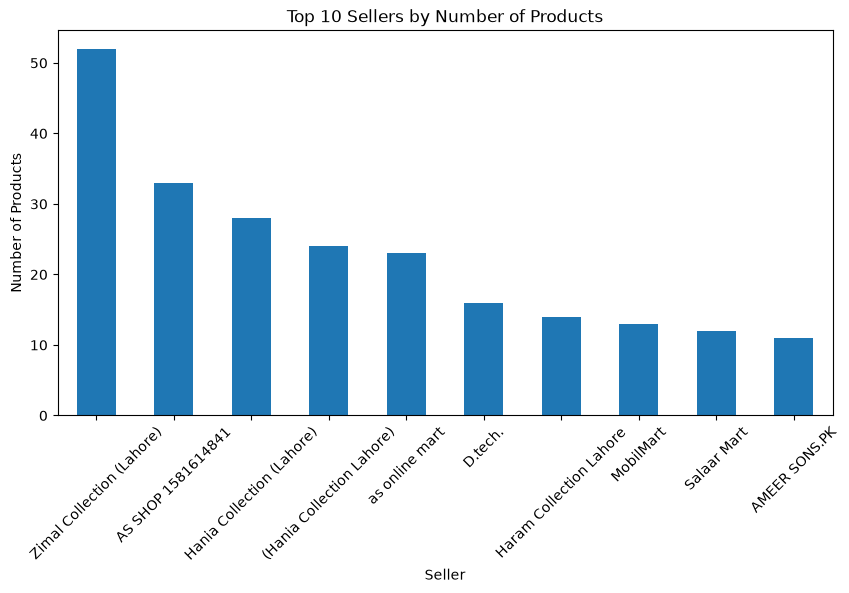

In [26]:
plt.figure(figsize=(10,5))

df['seller'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Sellers by Number of Products")
plt.xlabel("Seller")
plt.ylabel("Number of Products")

plt.xticks(rotation=45)
plt.show()

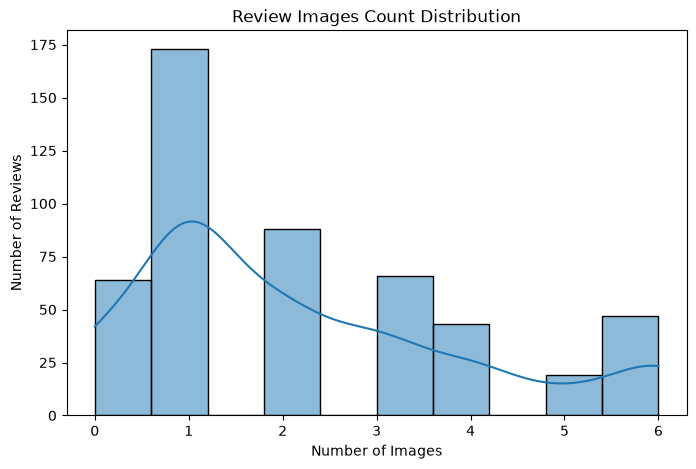

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(df['review_images_count'], bins=10, kde=True)

plt.title("Review Images Count Distribution")
plt.xlabel("Number of Images")
plt.ylabel("Number of Reviews")

plt.show()

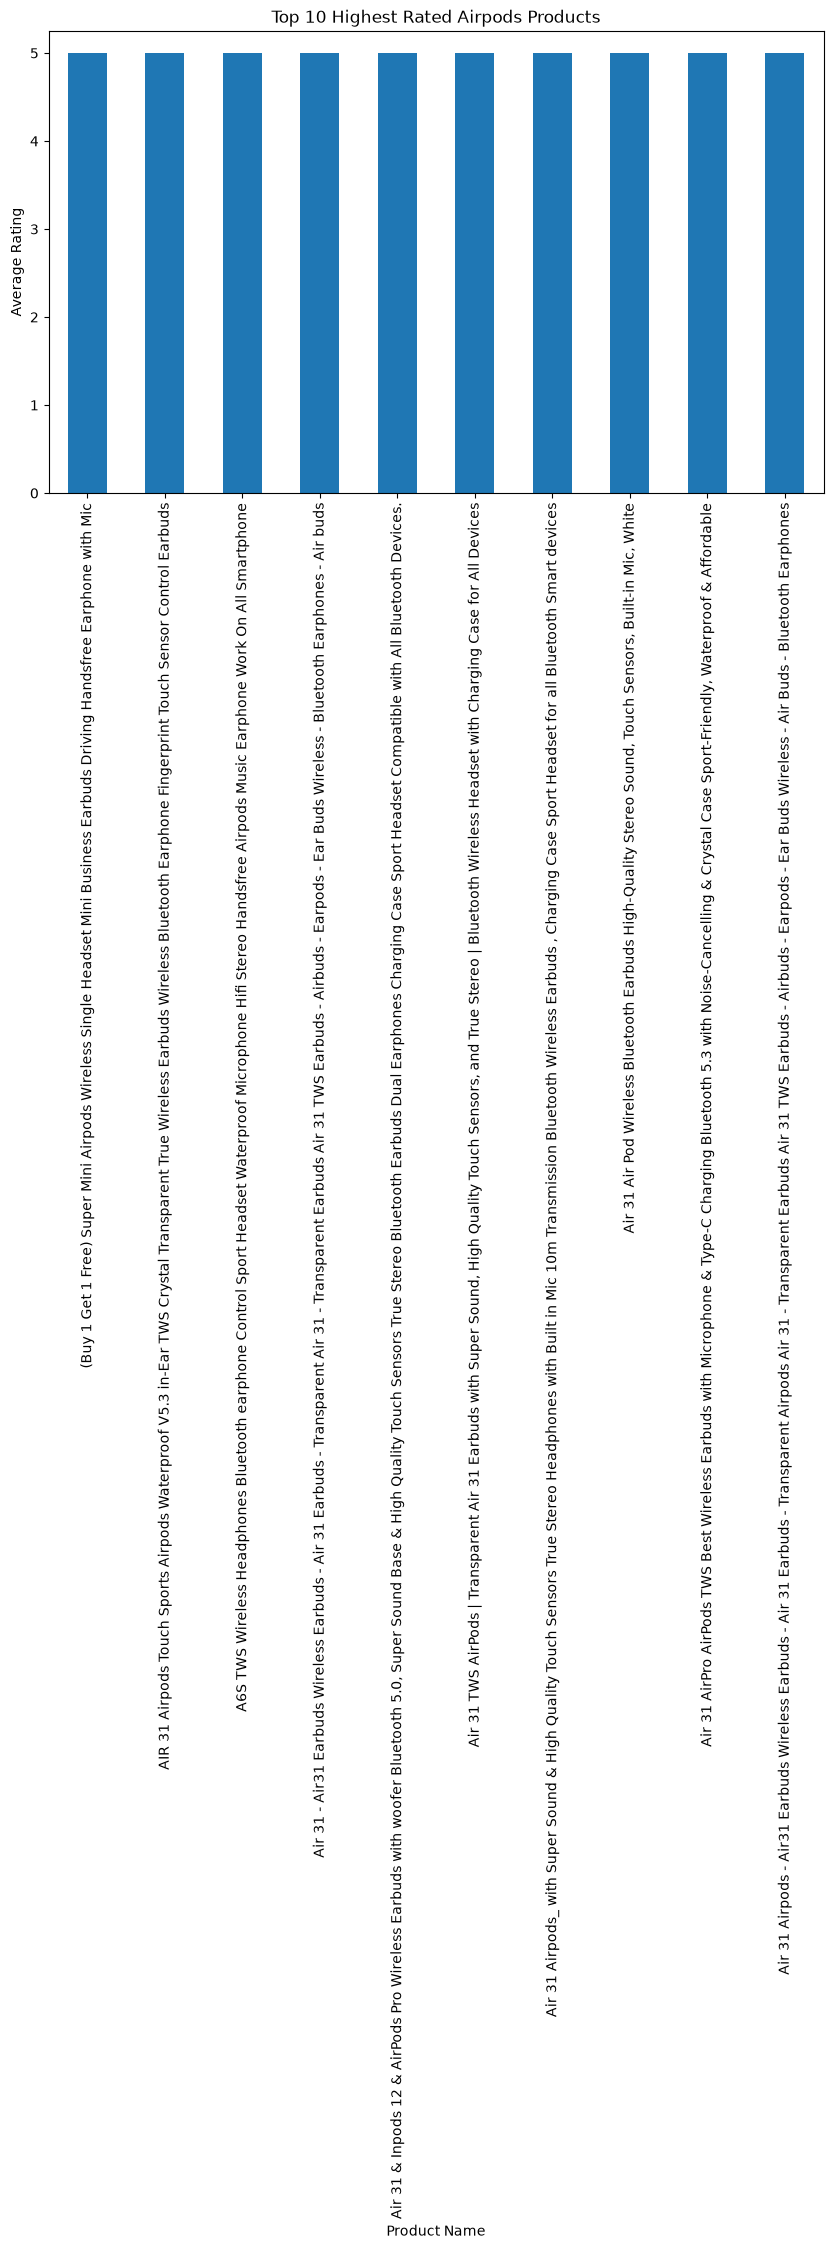

In [28]:
top_rated_products = (
    df.groupby('product_name')['review_rating']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

top_rated_products.plot(kind='bar')

plt.title("Top 10 Highest Rated Airpods Products")
plt.xlabel("Product Name")
plt.ylabel("Average Rating")

plt.xticks(rotation=90)
plt.show()

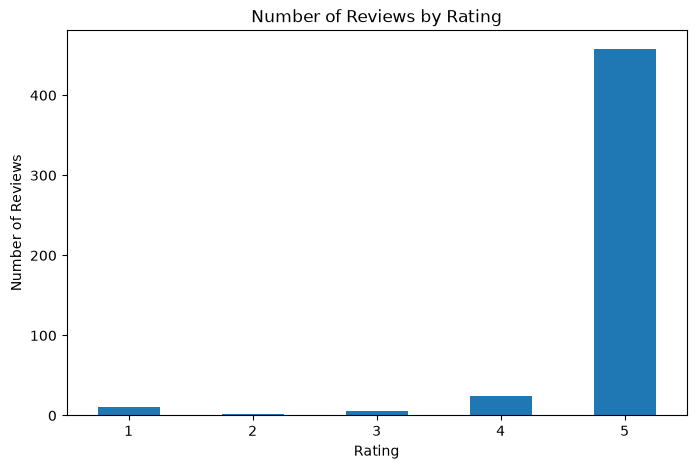

In [29]:
rating_counts = df['review_rating'].value_counts().sort_index()

plt.figure(figsize=(8,5))

rating_counts.plot(kind='bar')

plt.title("Number of Reviews by Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=0)
plt.show()

In [30]:
# Final EDA dataset verification

print("Dataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

Dataset Shape:
(500, 12)

Missing Values:
product_name           0
price                  0
ratings_count          0
seller                 0
review_rating          0
written_review         0
reviewer               0
bought_date            0
review_time            0
is_purchased           0
review_images_count    0
product_url            0
dtype: int64

Data Types:
product_name                      str
price                         float64
ratings_count                 float64
seller                            str
review_rating                   int64
written_review                    str
reviewer                          str
bought_date            datetime64[us]
review_time                       str
is_purchased                     bool
review_images_count             int64
product_url                       str
dtype: object


In [32]:
import os

print("Current location:")
print(os.getcwd())

print("\nOutput folder:")
print(os.listdir("../output"))

Current location:
C:\Users\hp\Desktop\Airpods_Analysis\notebooks

Output folder:
['airpods_cleaned.csv']


In [33]:
import pandas as pd

df_clean = pd.read_csv("../output/airpods_cleaned.csv")

df_clean.head()

,product_name,price,ratings_count,seller,review_rating,written_review,reviewer,bought_date,review_time,is_purchased,review_images_count,product_url
0,TWS Air pro Black Air pod_ with Super Sound & ...,789.0,11.0,Cano collection,5,omg the quality is very amazing I am very happ...,D***r,2026-08-12,2 weeks ago,True,1,https://www.daraz.pk/products/_-10-i1965762603...
1,Wireless Earbuds Headphones Bluetooth Earpods ...,323.0,187.0,AS SHOP 1581614841,5,𝐁𝐞𝐭𝐭𝐞𝐫 𝐐𝐮𝐚𝐥𝐢𝐭𝐲 Sound Quality:100% Battery Life...,0***0,2026-08-10,3 weeks ago,True,1,https://www.daraz.pk/products/-i1964603364.html
2,"Airbuds, Earbuds, Wireless Earbuds, Bluetooth ...",324.0,16.0,AS SHOP 1581614841,5,boht buri service hai Jo cheez dikhao us se 10...,Naveed,2026-08-29,2 days ago,True,1,https://www.daraz.pk/products/tws-hd-enc-led-i...
3,Original M10 & M90 TWS AIRPODS Wireless Earpho...,719.0,85.0,(Hania Collection Lahore),5,Totally Satisfied with the Quality of i12produ...,doopersuper534,2023-12-09,25 Dec 2023,True,6,https://www.daraz.pk/products/original-m10-m90...
4,New Air Pro True Wireless Airbuds Bluetooth Ea...,849.0,20.0,as online mart,5,Comfort: comfortable bi bhot hai easy se ear m...,a***a,2026-08-07,3 weeks ago,True,4,https://www.daraz.pk/products/-i1967525584.html


In [34]:
# Dataset information
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_name         500 non-null    str    
 1   price                500 non-null    float64
 2   ratings_count        500 non-null    float64
 3   seller               500 non-null    str    
 4   review_rating        500 non-null    int64  
 5   written_review       500 non-null    str    
 6   reviewer             500 non-null    str    
 7   bought_date          500 non-null    str    
 8   review_time          500 non-null    str    
 9   is_purchased         500 non-null    bool   
 10  review_images_count  500 non-null    int64  
 11  product_url          500 non-null    str    
dtypes: bool(1), float64(2), int64(2), str(7)
memory usage: 276.8 KB


In [35]:
df_clean.describe()

,price,ratings_count,review_rating,review_images_count
count,500.000000,500.000000,500.000000,500.000000
mean,847.136000,365.954000,4.836000,2.192000
std,530.692459,1049.093224,0.652653,1.774665
min,229.000000,1.000000,1.000000,0.000000
25%,686.500000,16.000000,5.000000,1.000000
50%,739.000000,36.000000,5.000000,2.000000
75%,849.000000,187.000000,5.000000,3.000000
max,5499.000000,6150.000000,5.000000,6.000000


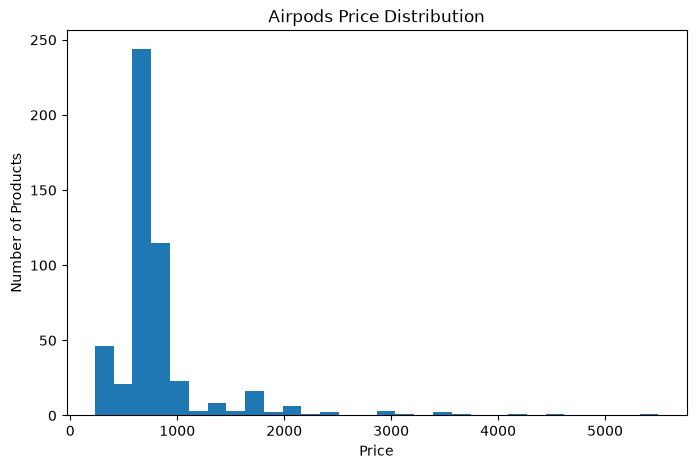

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_clean['price'], bins=30)
plt.title("Airpods Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Products")
plt.show()

In [1]:
blank_cols = [
    'brand',
    'original_price',
    'discount_percent',
    'seller_rating_percent',
    'ship_on_time_percent'
]

df_clean = df_clean.drop(columns=blank_cols)

df_clean.shape

NameError: name 'df_clean' is not defined